In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from utils import compute_H, warp_image, warp_points, align_and_blend_images, get_harris_corners, adaptive_non_maximal_suppression, extract_feature_descriptors, visualize_descriptors, match_features, ransac

In [ ]:
img = plt.imread('../data/IMG_8828.jpg')

with open('../data/card.json', 'r') as f:
    warped_points = json.load(f)

original_pts = np.array(warped_points["im1Points"])
new_pts = np.array(warped_points["im2Points"])

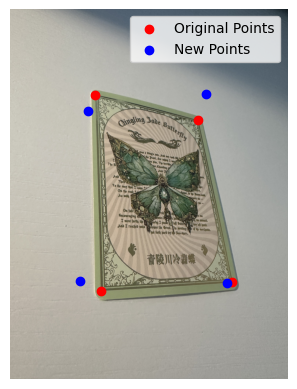

In [ ]:
# Plot the image
fig, ax = plt.subplots()

# Plot the image
ax.imshow(img)

# Plot the points on the image
ax.scatter(original_pts[:, 0], original_pts[:, 1], c='r', label='Original Points')
ax.scatter(new_pts[:, 0], new_pts[:, 1], c='b', label='New Points')

ax.legend()
ax.axis('off')
plt.show()

In [ ]:
# Compute the homography matrix
H = compute_H(original_pts, new_pts)
print(H)

[[ 5.87829631e-01 -1.18531288e-02  1.92919110e+02]
 [-5.48834751e-01  9.06532296e-01  6.20639121e+02]
 [-2.04363659e-04  5.46962171e-05  1.00000000e+00]]


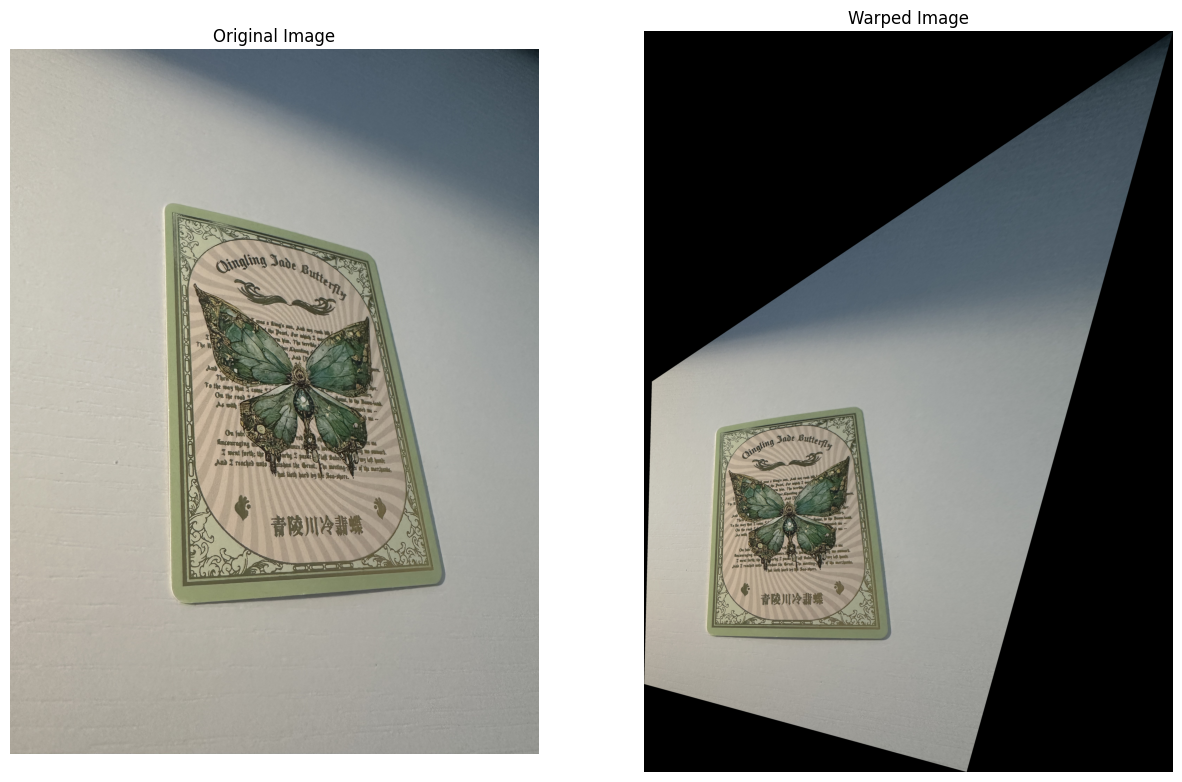

In [ ]:
im_warped, _, _ = warp_image(img, H)

# Display the result
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

# Original image
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Warped image
ax[1].imshow(im_warped)
ax[1].set_title('Warped Image')
ax[1].axis('off')

plt.show()

In [ ]:
image_left = plt.imread('../data/IMG_8868r.jpg')
image_right = plt.imread('../data/IMG_8869r.jpg')

with open('../data/card.json', 'r') as f:
    points = json.load(f)

image_left_pts = np.array(points["im1Points"])
image_right_pts = np.array(points["im2Points"])
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

# Plot the left image
ax[0].imshow(image_left)
ax[0].scatter(image_left_pts[:, 0], image_left_pts[:, 1], c='r', s=10, label='Left Points')
ax[0].set_title('Left Image')
ax[0].axis('off')

# Plot the right image
ax[1].imshow(image_right)
ax[1].scatter(image_right_pts[:, 0], image_right_pts[:, 1], c='b', s=10, label='Right Points')
ax[1].set_title('Right Image')
ax[1].axis('off')

plt.show()

NameError: name 'plt' is not defined

In [ ]:
image_right_pts = np.array([[0, 0], [0, 3500], [2500, 0], [2500, 3500]])

H = compute_H(image_left_pts, image_right_pts)

# Warp the right image to the left image's perspective
warped_left, min_x, min_y = warp_image(image_left, H)

# Warp the points from the right image to the left image's perspective
warped_points = warp_points(image_left_pts, H, min_x, min_y)
fig, ax = plt.subplots(figsize=(10, 7))

# Display the warped image
ax.imshow(warped_left)
ax.scatter(warped_points[:, 0], warped_points[:, 1], c='r', s=8, label='Warped Points')

ax.legend()
ax.set_title('Warped Image with Warped Points')
ax.axis('off')

plt.show()

NameError: name 'np' is not defined

In [ ]:
# Align and blend the images
manual_pts_result_img = align_and_blend_images(warped_left, image_right, warped_points, image_right_pts)

# Display the result
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(manual_pts_result_img)
ax.set_title('Aligned and Blended Image')
ax.axis('off')
plt.show()

NameError: name 'align_and_blend_images' is not defined